# Importing libraries

In [776]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits import mplot3d
from plotly.offline import download_plotlyjs, init_notebook_mode
from plotly.offline import plot, iplot
import plotly.graph_objects as go

# Importing data

In [777]:
path = r'C:\Users\thoma\OneDrive\Dokumente\data analytics\ML_Ach1\ClimateWins'

In [778]:
path

'C:\\Users\\thoma\\OneDrive\\Dokumente\\data analytics\\ML_Ach1\\ClimateWins'

In [779]:
weather = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'Weather_scaled.pkl'))

In [780]:
weather.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,-1.599964,0.660514,-0.02793,0.826097,-0.001949,-1.101066,-0.265148,-0.179228,-0.902918,...,-0.443701,0.761754,-1.299744,-0.806427,-0.088407,-0.024706,0.372147,-0.668215,-0.519743,-0.752237
1,19600102,-1.599964,0.244897,-0.02793,0.735760,-0.001949,-1.058108,1.658760,-0.179228,-0.810126,...,0.783085,1.183580,-1.262455,-1.042055,0.503361,-0.024706,-0.829285,-0.548046,-0.629054,-0.407141
2,19600103,-1.599964,1.076130,-0.02793,1.277781,-0.001949,-1.251420,0.155707,-0.179228,-1.065304,...,0.783085,1.183580,-0.432779,-1.136306,-0.396127,-0.024706,-1.009500,-0.067372,0.054135,-0.177078
3,19600104,-1.599964,-1.001953,-0.02793,1.458455,-0.001949,-0.821838,-0.445514,-0.179228,-0.114186,...,0.783085,0.480538,0.387574,-1.183432,0.669056,-0.024706,-1.039536,-0.998679,-0.164486,-0.838511
4,19600105,-1.599964,0.244897,-0.02793,1.729466,-0.001949,-0.746661,-0.164944,-0.179228,0.187388,...,-1.670486,-0.363113,1.729970,-0.794645,-0.490810,-0.024706,0.672505,-1.509396,-1.339569,-1.471186


In [781]:
weather.shape

(22950, 170)

In [782]:
# Reducing to just mean temperatures
weather.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_wind_speed',
       'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
       'BASEL_precipitation', 'BASEL_snow_depth', 'BASEL_sunshine',
       ...
       'VALENTIA_cloud_cover', 'VALENTIA_humidity', 'VALENTIA_pressure',
       'VALENTIA_global_radiation', 'VALENTIA_precipitation',
       'VALENTIA_snow_depth', 'VALENTIA_sunshine', 'VALENTIA_temp_mean',
       'VALENTIA_temp_min', 'VALENTIA_temp_max'],
      dtype='object', length=170)

In [783]:
# Filtering mean temperature columns
mean_temp = weather.filter(regex='temp_mean$', axis=1)

In [784]:
mean_temp.columns

Index(['BASEL_temp_mean', 'BELGRADE_temp_mean', 'BUDAPEST_temp_mean',
       'DEBILT_temp_mean', 'DUSSELDORF_temp_mean', 'GDANSK_temp_mean',
       'HEATHROW_temp_mean', 'KASSEL_temp_mean', 'LJUBLJANA_temp_mean',
       'MAASTRICHT_temp_mean', 'MADRID_temp_mean', 'MUNCHENB_temp_mean',
       'OSLO_temp_mean', 'ROMA_temp_mean', 'SONNBLICK_temp_mean',
       'STOCKHOLM_temp_mean', 'TOURS_temp_mean', 'VALENTIA_temp_mean'],
      dtype='object')

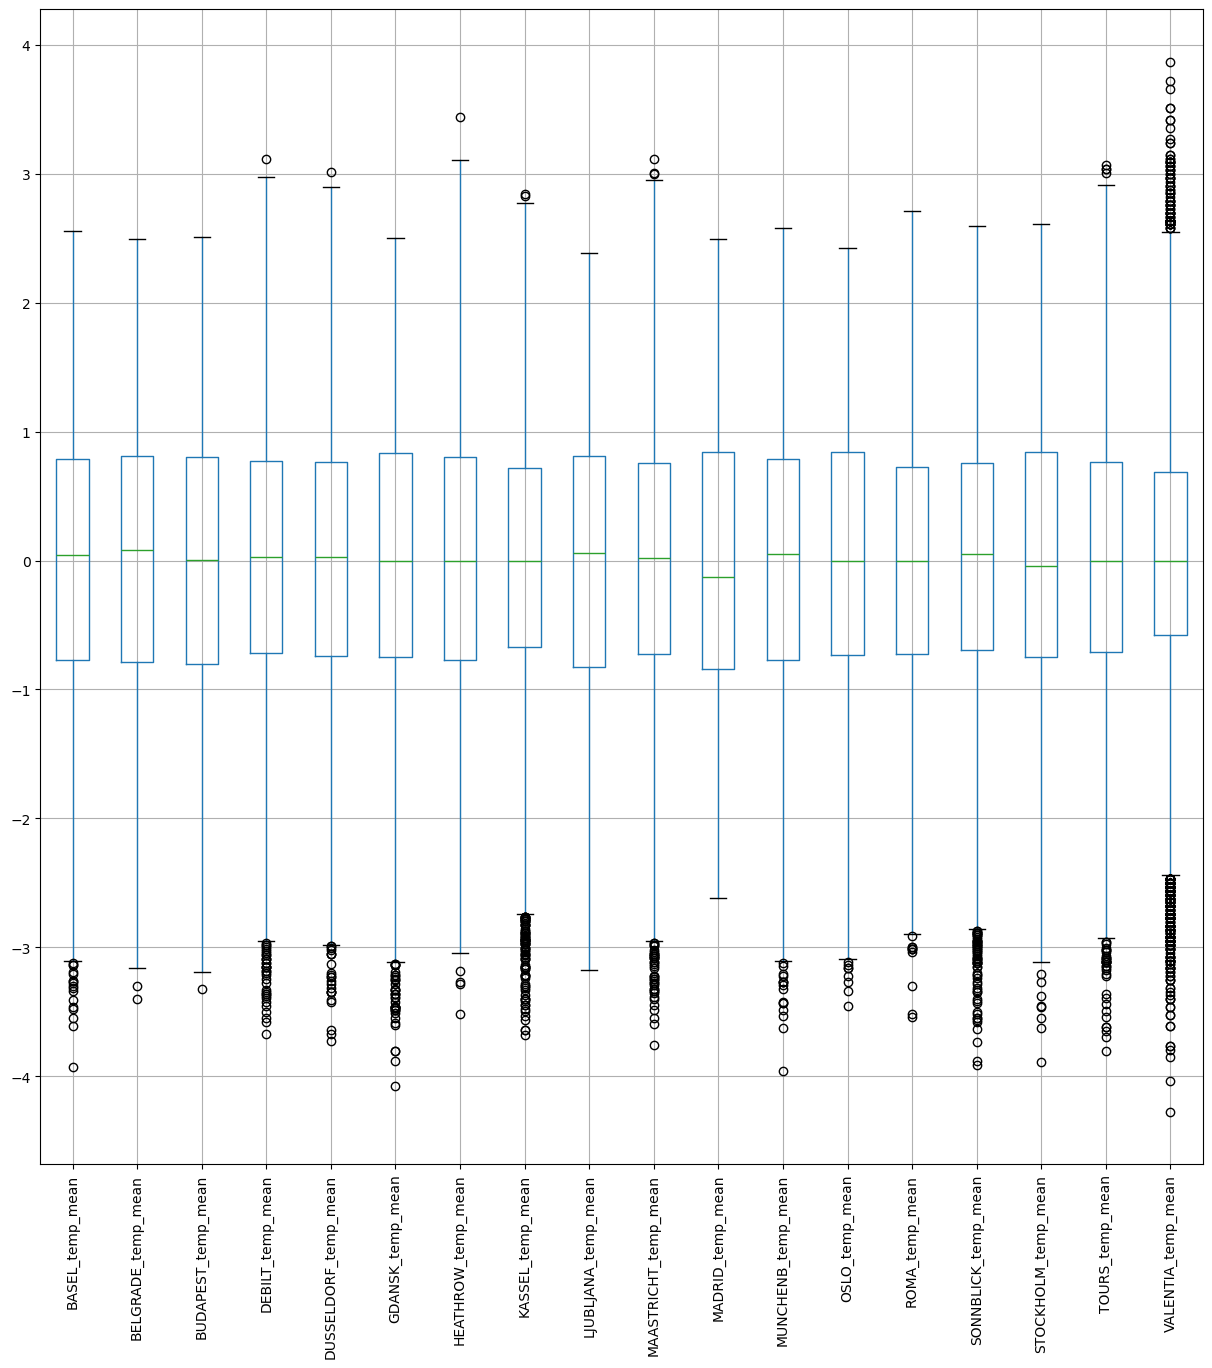

In [785]:
# Looking at a whisker plot of the data to see variations in temperatures
mean_temp.boxplot(figsize=(15,15))
plt.xticks(rotation=90)
plt.show()

In [786]:
# Reducing the dataset to a single year
df_year = weather[weather['DATE'].astype(str).str.contains('1990')]
df_year

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
10958,19900101,-1.599964,-2.248803,-0.027930,0.645423,0.563561,-0.800359,-0.445514,-0.179228,0.604953,...,-1.670486,-0.081896,-0.693801,-1.100962,0.112794,-0.024706,-0.438820,-1.148890,-0.929656,-1.183606
10959,19900102,-1.599964,-1.417570,-0.027930,0.735760,0.884527,-0.929233,-0.445514,-0.179228,-0.531750,...,-0.443701,-0.503721,-0.954822,-1.089181,1.260825,-0.024706,-1.009500,-1.028721,-0.875001,-1.039817
10960,19900103,-1.599964,1.076130,-0.027930,1.187444,0.777538,-1.229941,-0.445514,-0.179228,-1.065304,...,-1.057093,1.042971,-0.451424,-0.888897,-0.490810,-0.024706,0.432219,-0.878510,-0.847674,-0.809753
10961,19900104,-1.599964,-1.417570,-0.027930,0.103401,1.297196,-0.864796,-0.445514,-0.179228,0.233784,...,0.169692,1.464796,-0.283624,-1.183432,0.598044,-0.024706,-1.039536,-1.269058,-1.612845,-0.723479
10962,19900105,-1.599964,0.660514,-0.027930,0.464749,1.618161,-1.197722,-0.365351,-0.179228,-1.018908,...,-1.057093,1.183580,-0.320913,-1.100962,0.171971,-0.024706,-0.679106,-0.397835,-0.191813,-0.522173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11318,19901227,1.594371,0.660514,5.705005,-0.348283,-0.949560,-1.079587,-0.205026,-0.179228,-0.694136,...,0.169692,-1.347371,-0.721768,-1.018492,0.811081,-0.024706,-0.588999,-0.998679,-1.148277,-1.528702
11319,19901228,1.594371,-1.001953,0.791061,-0.438620,0.471857,-0.800359,-0.405433,-0.179228,0.465765,...,0.783085,0.058712,-1.961620,-1.136306,0.834752,-0.024706,-0.769214,-0.788384,-0.875001,-0.550931
11320,19901229,1.594371,0.660514,3.794027,-0.528957,-0.261778,-1.272899,0.576562,-0.179228,-1.042106,...,0.169692,-1.066155,-1.775176,-1.136306,0.716398,-0.024706,-1.009500,-1.899944,-1.312242,-1.816282
11321,19901230,1.594371,1.076130,1.337054,-0.167609,0.624698,-1.315857,0.576562,-0.179228,-1.065304,...,-0.443701,-0.644330,-0.814989,-1.006711,0.811081,-0.024706,-0.138462,-1.779775,-1.722155,-1.586218


In [787]:
df_year.describe()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
count,3.650000e+02,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,...,365.000000,365.000000,365.000000,365.000000,365.000000,3.650000e+02,365.000000,365.000000,365.000000,365.000000
mean,1.990067e+07,0.004762,-0.158194,0.013206,-0.169342,0.185606,-0.045913,0.001696,-0.005792,0.110676,...,0.083985,0.031361,0.058564,-0.027497,-0.056436,-2.470616e-02,-0.073947,0.135022,0.104597,0.154781
std,3.454755e+02,1.002610,1.087613,0.740024,0.963288,1.288116,0.965310,0.953020,0.909860,1.023726,...,1.112739,1.077445,1.117722,1.053039,0.646063,3.126788e-17,1.118295,1.096645,1.068290,1.145008
min,1.990010e+07,-1.599964,-2.248803,-2.484902,-2.968054,-4.495461,-1.315857,-0.445514,-0.179228,-1.065304,...,-3.510664,-3.456497,-3.863348,-1.195214,-0.490810,-2.470616e-02,-1.039536,-2.290492,-2.596636,-2.736537
25%,1.990040e+07,-0.728781,-1.001953,-0.027930,-0.799968,-0.613311,-0.886275,-0.445514,-0.179228,-0.879720,...,-0.443701,-0.784938,-0.535324,-0.912459,-0.490810,-2.470616e-02,-1.009500,-0.788384,-0.711036,-0.694721
50%,1.990070e+07,0.142401,0.244897,-0.027930,-0.167609,0.181460,-0.231162,-0.445514,-0.179228,-0.021394,...,0.169692,0.058712,0.219774,-0.429421,-0.348786,-2.470616e-02,-0.498891,0.142923,0.163445,0.052986
75%,1.990100e+07,1.013583,0.660514,-0.027930,0.555086,0.899811,0.660220,0.035463,-0.179228,0.906527,...,0.783085,0.902363,0.816395,0.713377,0.160135,-2.470616e-02,0.522326,0.863935,0.901288,0.886967
max,1.990123e+07,1.594371,1.076130,7.615984,1.729466,4.078894,2.088581,6.007594,7.796099,2.298407,...,1.396477,2.308447,2.513035,2.657311,3.000625,-2.470616e-02,3.345692,2.966887,2.677577,4.050343


In [788]:
df = df_year.drop(['DATE','MONTH'], axis=1)

In [789]:
df

,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
10958,-2.248803,-0.027930,0.645423,0.563561,-0.800359,-0.445514,-0.179228,0.604953,-1.696559,-1.520087,...,-1.670486,-0.081896,-0.693801,-1.100962,0.112794,-0.024706,-0.438820,-1.148890,-0.929656,-1.183606
10959,-1.417570,-0.027930,0.735760,0.884527,-0.929233,-0.445514,-0.179228,-0.531750,-1.655817,-1.566071,...,-0.443701,-0.503721,-0.954822,-1.089181,1.260825,-0.024706,-1.009500,-1.028721,-0.875001,-1.039817
10960,1.076130,-0.027930,1.187444,0.777538,-1.229941,-0.445514,-0.179228,-1.065304,-1.710140,-1.612055,...,-1.057093,1.042971,-0.451424,-0.888897,-0.490810,-0.024706,0.432219,-0.878510,-0.847674,-0.809753
10961,-1.417570,-0.027930,0.103401,1.297196,-0.864796,-0.445514,-0.179228,0.233784,-1.506430,-1.443447,...,0.169692,1.464796,-0.283624,-1.183432,0.598044,-0.024706,-1.039536,-1.269058,-1.612845,-0.723479
10962,0.660514,-0.027930,0.464749,1.618161,-1.197722,-0.365351,-0.179228,-1.018908,-1.411366,-1.443447,...,-1.057093,1.183580,-0.320913,-1.100962,0.171971,-0.024706,-0.679106,-0.397835,-0.191813,-0.522173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11318,0.660514,5.705005,-0.348283,-0.949560,-1.079587,-0.205026,-0.179228,-0.694136,-0.515042,-0.692371,...,0.169692,-1.347371,-0.721768,-1.018492,0.811081,-0.024706,-0.588999,-0.998679,-1.148277,-1.528702
11319,-1.001953,0.791061,-0.438620,0.471857,-0.800359,-0.405433,-0.179228,0.465765,-0.895301,-0.723027,...,0.783085,0.058712,-1.961620,-1.136306,0.834752,-0.024706,-0.769214,-0.788384,-0.875001,-0.550931
11320,0.660514,3.794027,-0.528957,-0.261778,-1.272899,0.576562,-0.179228,-1.042106,-0.012558,-0.370482,...,0.169692,-1.066155,-1.775176,-1.136306,0.716398,-0.024706,-1.009500,-1.899944,-1.312242,-1.816282
11321,1.076130,1.337054,-0.167609,0.624698,-1.315857,0.576562,-0.179228,-1.065304,0.218313,0.303953,...,-0.443701,-0.644330,-0.814989,-1.006711,0.811081,-0.024706,-0.138462,-1.779775,-1.722155,-1.586218


In [790]:
# Plotting all weather data for all stations for a year 

#X = weather station
#Y = day of the year
#Z = temperature

fig = go.Figure(data=[go.Surface(z=df.values)])
fig.update_layout(title='Temperatures over time', autosize=False,
                  width=600, height=600)
fig.show()

In [791]:
# Indexing - creating a set of data from 1 to 365 (as 1990 was no leap year!)
# Scaling by 100 as the index is made. This will help the gradient descent converge 365 = 3.65
i = np.arange(0.01,3.66,0.01)
index = pd.DataFrame(data = i, columns = ['index'])
index

,index
0,0.01
1,0.02
2,0.03
3,0.04
4,0.05
...,...
360,3.61
361,3.62
362,3.63
363,3.64


In [792]:
n_rows = df_year.shape[0]
n_rows

365

In [793]:
# Translating chosen weather data into X and y datasets needed for the optimization function
X=index.to_numpy().reshape(n_rows,1)
# Representing x_0 as a vector of 1s for vector computation
ones = np.ones((n_rows,1))
X = np.concatenate((ones, X), axis=1)
y=df_year['MADRID_temp_mean'].to_numpy().reshape(n_rows,1)

In [794]:
X.shape, y.shape

((365, 2), (365, 1))

In [795]:
# Looking at one year of temperature data over time
plt.scatter(x=index['index'], y=df_year['MADRID_temp_mean'])
plt.xlabel('X'); plt.ylabel('y');
plt.title('Input dataset');

In [796]:
# What's the min temperature? (Note gradient descent is not actually finding this number)
df_year['MADRID_temp_mean'].min()

-1.743109449208083

In [797]:
# What's the max temperature? (Note gradient descent is not actually finding this number)
df_year['MADRID_temp_mean'].max()

2.1658266305512592

In [798]:
# Computing the loss function for the gradiant descent

def compute_cost(X, y, theta=np.array([[0],[0]])):
    """Given covariate matrix X, the prediction results y and coefficients theta
    compute the loss"""
    
    m = len(y)
    J=0 # initializing loss to zero
    
    # reshaping theta
    theta=theta.reshape(2,1)
    
    # calculating the hypothesis - y_hat
    h_x = np.dot(X,theta)
    #print(h_x)
    
    # subtracting y from y_hat, square and sum
    error_term = sum((h_x - y)**2)
    
    # dividing by twice the number of samples - standard practice.
    loss = error_term/(2*m)
    
    return loss

In [799]:
compute_cost(X,y)

array([0.52425693])

In [800]:
# Gradiant descent function

def gradient_descent(X, y, theta=np.array([[0],[0]]),
                    alpha=0.01, num_iterations=1500):
    """
    Solve for theta using Gradient Descent optimiztion technique. 
    Alpha is the learning rate
    """
    m = len(y)
    J_history = []
    theta0_history = []
    theta1_history = []
    theta = theta.reshape(2,1)
    
    for i in range(num_iterations):
        error = (np.dot(X, theta) - y)
        
        term0 = (alpha/m) * sum(error* X[:,0].reshape(m,1))
        term1 = (alpha/m) * sum(error* X[:,1].reshape(m,1))
        
        # updating theta
        term_vector = np.array([[term0],[term1]])
        #print(term_vector)
        theta = theta - term_vector.reshape(2,1)
        
        # storing history values
        theta0_history.append(theta[0].tolist()[0])
        theta1_history.append(theta[1].tolist()[0])
        J_history.append(compute_cost(X,y,theta).tolist()[0])
        
    return (theta, J_history, theta0_history, theta1_history)

In [801]:
%%time
# Running the data through a gradiant descent for starting conditions in 'theta_init.'
# And adjusting numbers

num_iterations=100 #<---Deciding on how many iterations are needed, starting small and working up. Over 10,000 iterations will take a few seconds.
theta_init=np.array([[1],[-1]]) #<---Putting a guess for [theta0], [theta1], while starting with 1 and 1.
alpha=0.01 #<---Deciding on the step size, trying values between 0.1 and 0.00001 and adjusting iterations.
# If the solution is not converging -> smaller step size
theta, J_history, theta0_history, theta1_history = gradient_descent(X,y, theta_init,
                                                                   alpha, num_iterations)

CPU times: total: 297 ms
Wall time: 328 ms


In [802]:
theta

array([[ 0.96384234],
       [-0.36714248]])

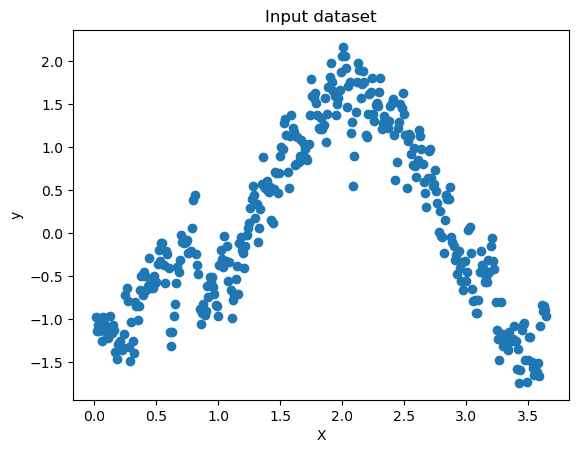

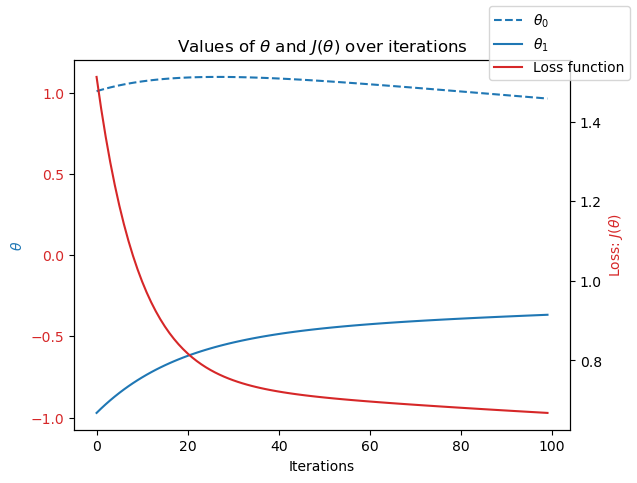

In [803]:
# Plotting the loss, theta0, and theta1. If the result is looking like a straight line, it's not converging on an answer!
# Theloss (in red) should be trending towards 0.

fig, ax1 = plt.subplots()

# Plot thetas over time
color='tab:blue'
ax1.plot(theta0_history, label='$\\theta_{0}$', linestyle='--', color=color)
ax1.plot(theta1_history, label='$\\theta_{1}$', linestyle='-', color=color)
# ax1.legend()
ax1.set_xlabel('Iterations'); ax1.set_ylabel('$\\theta$', color=color);
ax1.tick_params(axis='y', labelcolor=color)

# Plotting loss function over time
color='tab:red'
ax2 = ax1.twinx()
ax2.plot(J_history, label='Loss function', color=color)
ax2.set_title('Values of $\\theta$ and $J(\\theta)$ over iterations')
ax2.set_ylabel('Loss: $J(\\theta)$', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# ax2.legend();
fig.legend();

# plot
plt.show()

In [804]:
%%time
# Theta range
theta0_vals = np.linspace(3,-3,100) # Looking in the chart above for the limits of where theta0 and theta1 appear.
theta1_vals = np.linspace(3,-3,100) # Putting those values as the first two "linspace" numbers in these lines
                                      # Selecting with large margins, maybe +/- 10
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

# Computing cost for each combination of theta
c1=0; c2=0
for i in theta0_vals:
    for j in theta1_vals:
        t = np.array([i, j])
        J_vals[c1][c2] = compute_cost(X, y, t.transpose()).tolist()[0]
        c2=c2+1
    c1=c1+1
    c2=0 # reinitializing to 0

CPU times: total: 9 s
Wall time: 9.53 s


In [805]:
# Showing the loss function

#X = Theta0
#Y = Theta1
#Z = Loss
# Finding where it is closest to 0 in X and Y!

fig = go.Figure(data=[go.Surface(x=theta1_vals, y=theta0_vals, z=J_vals)])
fig.update_layout(title='Loss function for different thetas', autosize=True,
                  width=600, height=600, xaxis_title='theta0', 
                 yaxis_title='theta1')
fig.show()

In [806]:
# Same figure as above, with the line the loss function takes towards the minimum.

#X = Theta0
#Y - Theta1
#Z = Loss
#Black line = path of loss function over the iterations.
#Where is it closest to 0 in X and Y!?

line_marker = dict(color='#101010', width=2)
fig = go.Figure()
fig.add_surface(x=theta1_vals, y=theta0_vals, z=J_vals)
fig.add_scatter3d(x=theta1_history, y=theta0_history, z=J_history, line=line_marker, name='')
# Below line adds a graph of just the loss over iterations in a 2D plane
plt.plot(theta0_history, theta1_history, 'r+');
fig.update_layout(title='Loss function for different thetas', autosize=True,
                  width=600, height=600, xaxis_title='theta0', 
                 yaxis_title='theta1')
fig.show()

In [807]:
# Rerunning the optimization above, but this time starting closer to the objective!
# Finding where the black line ends near the lowest X/Y/Z coordinate and making that the guess below.

num_iterations=10000 #<---starting with the same iterations as above
theta_init=np.array([[0],[-0.7]]) #<---making a guess as to a more accurate [x],[y] coordinates near the minimum in the graph above.
alpha= 0.0001 #<---starting with the same step size as above
theta1, J_history1, theta0_history1, theta1_history1 = gradient_descent(X,y, theta_init,
                                                                   alpha, num_iterations)

In [808]:
# Looking at the new loss path on the function, should be starting much closer to the goal

line_marker = dict(color='#101010', width=2)
fig = go.Figure()
fig.add_surface(x=theta1_vals, y=theta0_vals, z=J_vals)
fig.add_scatter3d(x=theta1_history1, y=theta0_history1, z=J_history1, line=line_marker, name='')
# Below line adds a graph of just the loss over iterations in a 2D plane
plt.plot(theta0_history1, theta1_history1, 'r+');
fig.update_layout(title='Loss function for different thetas', autosize=True,
                  width=600, height=600, xaxis_title='theta0', 
                 yaxis_title='theta1')
fig.show()

In [809]:
# Saving
fig.write_html("loss_function.html")
fig.write_image("loss_function.png")